In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import KFold, GridSearchCV
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [33]:
Data = pd.read_csv('../data/processed_data.csv')
df = pd.DataFrame(Data)

In [34]:
def Logreg(X, y, Testsize, solvers=['liblinear', 'lbfgs', 'newton-cg', 'sag', 'saga']):
    eval_list = []
    y_pred = None

    for x in Testsize:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=x, random_state=0
        )

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        for solver_name in solvers:
            try:
                logreg = LogisticRegression(
                    solver=solver_name,
                    class_weight='balanced',
                    max_iter=1000,
                    random_state=0
                )
                logreg.fit(X_train_scaled, y_train)

                y_pred = logreg.predict(X_test_scaled)

                acc = metrics.accuracy_score(y_test, y_pred)
                f1 = metrics.f1_score(y_test, y_pred, average='macro')

                eval_list.append({
                    'Test_size': x,
                    'Solver': solver_name,
                    'acc': acc,
                    'score': f1
                })
            except Exception as e:
                print(f"Solver {solver_name} with test_size {x} failed: {e}")

    df_evaluation = pd.DataFrame(eval_list)

    if not df_evaluation.empty:
        df_evaluation = df_evaluation.set_index(['Test_size', 'Solver'])

    return df_evaluation

In [35]:
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: #90ee90; color: black; font-weight: bold;' if v else '' for v in is_max]

In [36]:
X = df.drop(columns=['Personal Loan', 'Place', 'ID'], errors='ignore')
X = pd.get_dummies(X, drop_first=True)
y = df['Personal Loan']

In [37]:
df_eval = Logreg(X, y, [0.1, 0.15, 0.2, 0.25, 0.3, 0.35])

df_eval.style.apply(highlight_max, subset=['acc', 'score'])

In [38]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

solvers = [
    "liblinear",
    "lbfgs",
    "newton-cg",
    "sag",
    "saga"
]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for solver in solvers:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            solver=solver,
            max_iter=1000,
            class_weight='balanced',
            random_state=42
        ))
    ])

    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    scores_1d = np.round(scores, 3).tolist()
    mean_score = round(scores.mean(), 4)

    print(f"{solver:<10} : {scores_1d} | Mean: {mean_score}")

liblinear  : [0.901, 0.903, 0.888, 0.891, 0.889] | Mean: 0.8944
lbfgs      : [0.901, 0.904, 0.887, 0.892, 0.891] | Mean: 0.895
newton-cg  : [0.901, 0.904, 0.888, 0.892, 0.889] | Mean: 0.8948
sag        : [0.901, 0.904, 0.888, 0.892, 0.89] | Mean: 0.895
saga       : [0.901, 0.904, 0.888, 0.892, 0.89] | Mean: 0.895


In [39]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

logreg = LogisticRegression(solver='newton-cg', max_iter=5000)


params = {
    'C': [0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50, 100, 200, np.inf],
    'class_weight': [None, 'balanced'],
    'warm_start': [False, True]
}

kfold = KFold(n_splits=5, shuffle=True, random_state=1)
gridsearch = GridSearchCV(
    estimator=logreg,
    param_grid=params,
    scoring='f1',
    n_jobs=-1,
    cv=kfold
)

gridsearch.fit(X_scaled, y)

print("Best Score (F1):", gridsearch.best_score_)
print("Best Parameters:", gridsearch.best_params_)

Best Score (F1): 0.710615115161807
Best Parameters: {'C': 1, 'class_weight': None, 'warm_start': False}


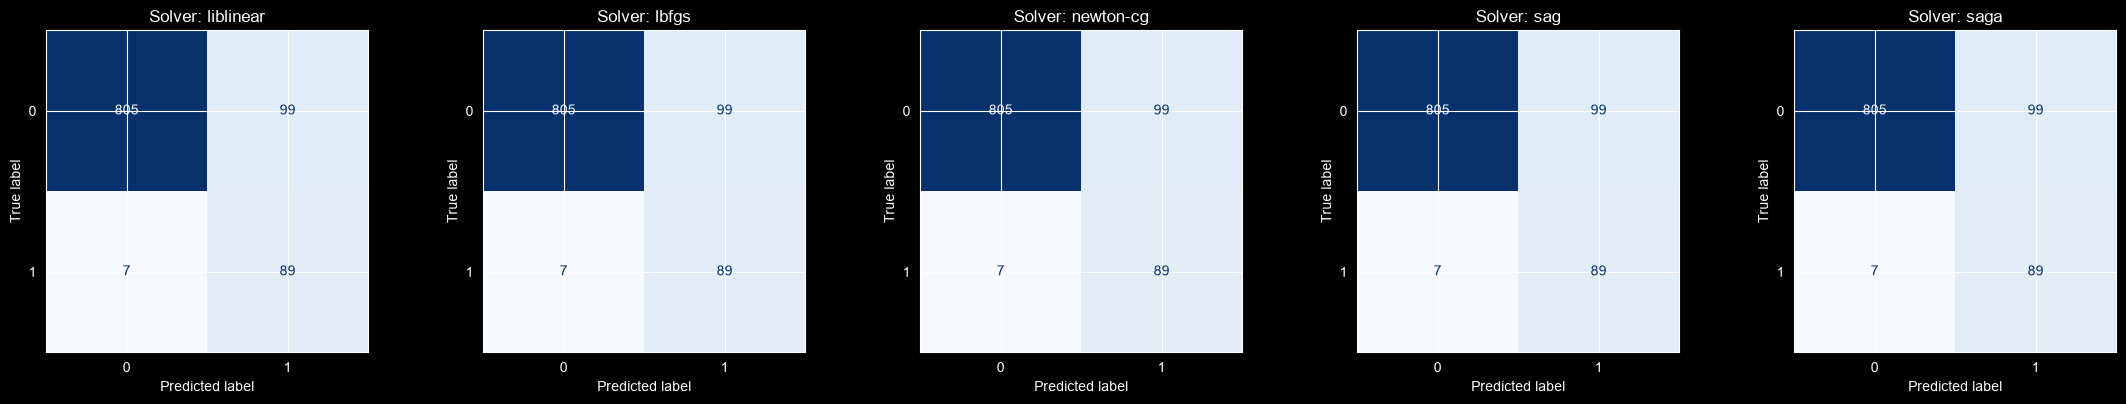

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

solvers = ['liblinear', 'lbfgs', 'newton-cg', 'sag', 'saga']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for idx, solver_name in enumerate(solvers):
    model = LogisticRegression(
        solver=solver_name,
        class_weight='balanced',
        max_iter=1000,
        random_state=0
    )
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1'])
    disp.plot(cmap='Blues', values_format='d', ax=axes[idx], colorbar=False)
    axes[idx].set_title(f"Solver: {solver_name}")

plt.tight_layout()
plt.show()

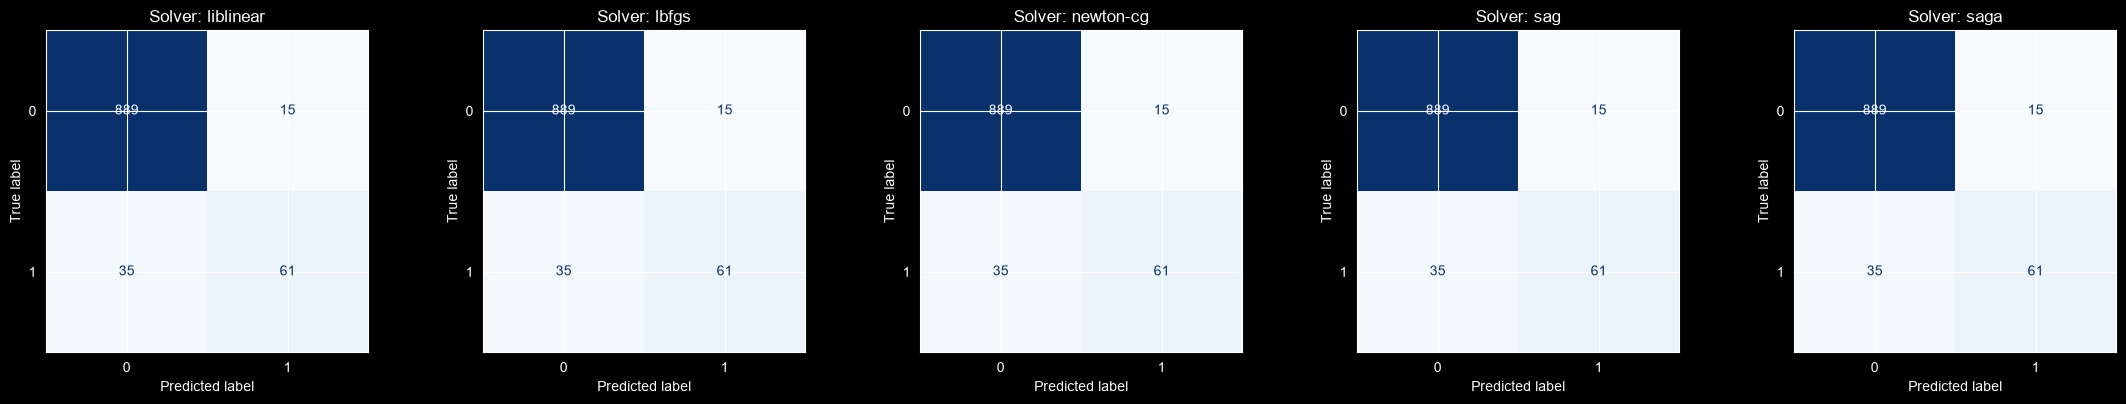

           Accuracy  Precision  Recall  F1-Score
Solver                                          
liblinear      0.95     0.8026  0.6354    0.7093
lbfgs          0.95     0.8026  0.6354    0.7093
newton-cg      0.95     0.8026  0.6354    0.7093
sag            0.95     0.8026  0.6354    0.7093
saga           0.95     0.8026  0.6354    0.7093


In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

solvers = ['liblinear', 'lbfgs', 'newton-cg', 'sag', 'saga']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
metrics_list = []

for idx, solver_name in enumerate(solvers):
    model = LogisticRegression(
        solver=solver_name,
        max_iter=1000,
        random_state=0
    )
    model.fit(X_train_scaled, y_train)

    y_probs = model.predict_proba(X_test_scaled)[:, 1]
    y_pred_custom = (y_probs >= 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred_custom)
    prec = precision_score(y_test, y_pred_custom)
    rec = recall_score(y_test, y_pred_custom)
    f1 = f1_score(y_test, y_pred_custom)

    metrics_list.append({
        'Solver': solver_name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })

    cm = confusion_matrix(y_test, y_pred_custom)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1'])
    disp.plot(cmap='Blues', values_format='d', ax=axes[idx], colorbar=False)
    axes[idx].set_title(f"Solver: {solver_name}")

plt.tight_layout()
plt.show()

df_metrics = pd.DataFrame(metrics_list).set_index('Solver')
print(df_metrics)